# Cora — GCN vs GAT: a K / F' sweep
This notebook **visualizes** results only. All training logic lives in `experiment.py`.

We sweep the two core GAT hyperparameters around the Veličković baseline (K=8, F'=8):
- **K** (attention heads) ∈ {1, 2, 4, 8, 16}, with F'=8 fixed
- **F'** (hidden dims per head) ∈ {4, 8, 16, 32, 64}, with K=8 fixed

Run the study first (≈10 configs × 5 seeds):
```bash
python experiment.py
```
That produces `results.csv`, which the cells below load and plot.

In [6]:
%%capture
!pip install torch-geometric certifi scipy scikit-learn pandas matplotlib ipywidgets

In [7]:
# Force-reload experiment so the kernel always uses the current file on disk,
# not a stale cached version from a previous session.
import importlib
import experiment
importlib.reload(experiment)
from experiment import run_experiment, summarize, build_model, set_seed, data, make_gcn_config, make_gat_config

%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [8]:
# Only runs the sweep if results.csv is missing or has the old format (no 'name' column).
# To force a re-run, delete results.csv first.
import os, pandas as _pd
_needs_run = True
if os.path.exists("results.csv"):
    _cols = _pd.read_csv("results.csv", nrows=0).columns.tolist()
    _needs_run = "name" not in _cols

if _needs_run:
    print("Running experiment (≈10 min)...")
    df = run_experiment()
else:
    print("results.csv already exists with correct format — skipping re-run.")

results.csv already exists with correct format — skipping re-run.


In [9]:
df = pd.read_csv("results.csv")

In [10]:
summarize(df)

,kind,K,Fp,KxFp,test_mean,test_std,gap_mean,mad_mean,conv_epoch,params,flops,runs,ms_per_epoch
name,,,,,,,,,,,,,
GAT_K1_F8,GAT,1,8,8,0.7494,0.0375,0.5256,0.7950,464.6,11565,63342360,5,33.8678
GAT_K2_F8,GAT,2,8,16,0.8006,0.0131,0.5485,0.8784,400.8,23109,126241368,5,38.7472
GAT_K8_F4,GAT,8,4,32,0.8052,0.0137,0.5332,0.8934,293.6,46197,252039384,5,54.6734
GAT_K8_F8,GAT,8,8,64,0.8072,0.0122,0.5298,0.8896,228.0,92373,503635416,5,54.6105
GCN_H16,GCN,1,16,16,0.8060,0.0076,0.5425,0.8087,302.4,23063,125270216,5,15.2155


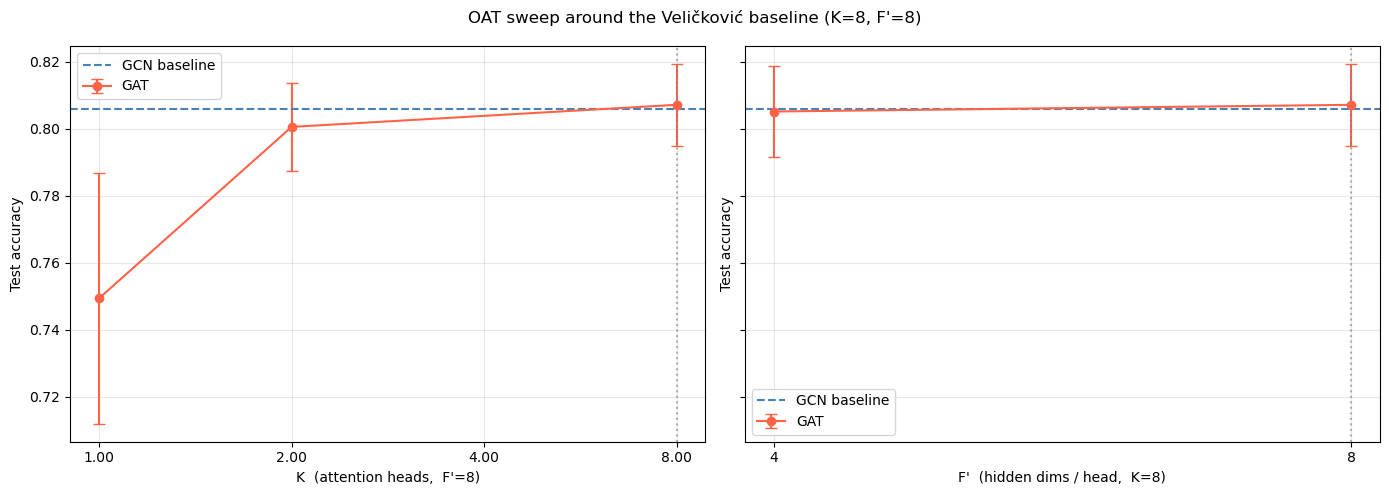

In [11]:
# Sweep curves: test accuracy vs K (F'=8) and vs F' (K=8).
s = summarize(df).reset_index()
gat     = s[s["kind"] == "GAT"]
gcn_acc = s[s["kind"] == "GCN"]["test_mean"].iloc[0]

k_line  = gat[gat["Fp"] == 8].sort_values("K")
fp_line = gat[gat["K"]  == 8].sort_values("Fp")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].errorbar(k_line["K"], k_line["test_mean"], yerr=k_line["test_std"],
                 marker="o", capsize=4, color="tomato", label="GAT")
axes[0].set_xlabel("K  (attention heads,  F'=8)")
axes[0].set_xticks(k_line["K"])

axes[1].errorbar(fp_line["Fp"], fp_line["test_mean"], yerr=fp_line["test_std"],
                 marker="o", capsize=4, color="tomato", label="GAT")
axes[1].set_xlabel("F'  (hidden dims / head,  K=8)")
axes[1].set_xticks(fp_line["Fp"])

for ax in axes:
    ax.set_xscale("log", base=2)
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.axhline(gcn_acc, ls="--", color="steelblue", label="GCN baseline")
    ax.axvline(8, ls=":", color="gray", alpha=0.6)
    ax.set_ylabel("Test accuracy")
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle("OAT sweep around the Veličković baseline (K=8, F'=8)")
plt.tight_layout()
plt.savefig("sweep_curves.png", dpi=150)
plt.show()

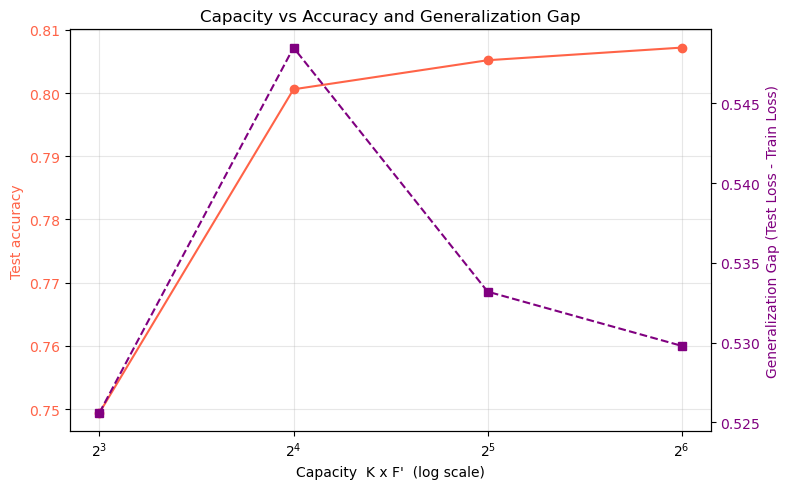

In [12]:
# Overfitting gap (test loss - train loss) and test accuracy vs capacity K x F'.
s       = summarize(df).reset_index()
gat_cap = s[s["kind"] == "GAT"].sort_values("KxFp")

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(gat_cap["KxFp"], gat_cap["test_mean"], "o-", color="tomato", label="Test acc")
ax1.set_xscale("log", base=2)
ax1.set_xlabel("Capacity  K x F'  (log scale)")
ax1.set_ylabel("Test accuracy", color="tomato")
ax1.tick_params(axis="y", labelcolor="tomato")

ax2 = ax1.twinx()
# Updated label to reflect loss-based gap
ax2.plot(gat_cap["KxFp"], gat_cap["gap_mean"], "s--", color="purple", label="Loss Gap")
ax2.set_ylabel("Generalization Gap (Test Loss - Train Loss)", color="purple")
ax2.tick_params(axis="y", labelcolor="purple")

ax1.set_title("Capacity vs Accuracy and Generalization Gap")
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
'''
# Overfitting gap (train - val) and test accuracy vs capacity K x F'.
s       = summarize(df).reset_index()
gat_cap = s[s["kind"] == "GAT"].sort_values("KxFp")

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(gat_cap["KxFp"], gat_cap["test_mean"], "o-", color="tomato", label="Test acc")
ax1.set_xscale("log", base=2)
ax1.set_xlabel("Capacity  K x F'  (log scale)")
ax1.set_ylabel("Test accuracy", color="tomato")
ax1.tick_params(axis="y", labelcolor="tomato")

ax2 = ax1.twinx()
ax2.plot(gat_cap["KxFp"], gat_cap["gap_mean"], "s--", color="purple", label="Gap (train - val)")
ax2.set_ylabel("Overfitting gap  (train - val)", color="purple")
ax2.tick_params(axis="y", labelcolor="purple")

ax1.set_title("Capacity vs accuracy and overfitting")
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("overfitting.png", dpi=150)
plt.show()
'''

'\n# Overfitting gap (train - val) and test accuracy vs capacity K x F\'.\ns       = summarize(df).reset_index()\ngat_cap = s[s["kind"] == "GAT"].sort_values("KxFp")\n\nfig, ax1 = plt.subplots(figsize=(8, 5))\nax1.plot(gat_cap["KxFp"], gat_cap["test_mean"], "o-", color="tomato", label="Test acc")\nax1.set_xscale("log", base=2)\nax1.set_xlabel("Capacity  K x F\'  (log scale)")\nax1.set_ylabel("Test accuracy", color="tomato")\nax1.tick_params(axis="y", labelcolor="tomato")\n\nax2 = ax1.twinx()\nax2.plot(gat_cap["KxFp"], gat_cap["gap_mean"], "s--", color="purple", label="Gap (train - val)")\nax2.set_ylabel("Overfitting gap  (train - val)", color="purple")\nax2.tick_params(axis="y", labelcolor="purple")\n\nax1.set_title("Capacity vs accuracy and overfitting")\nax1.grid(True, alpha=0.3)\nplt.tight_layout()\nplt.savefig("overfitting.png", dpi=150)\nplt.show()\n'

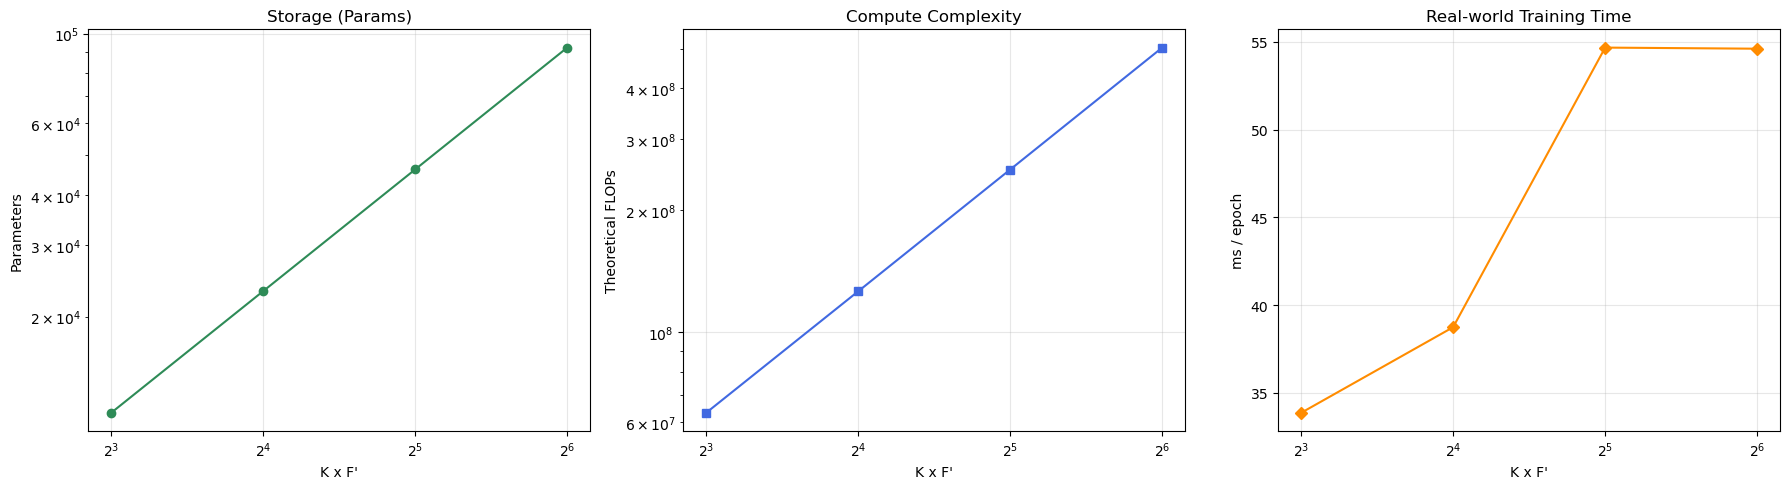

In [14]:
# Model Size (Params), Complexity (FLOPs), and Time vs capacity.
s       = summarize(df).reset_index()
gat_cap = s[s["kind"] == "GAT"].sort_values("KxFp")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Subplot 1: Parameters
axes[0].plot(gat_cap["KxFp"], gat_cap["params"], "o-", color="seagreen")
axes[0].set_yscale("log")
axes[0].set_ylabel("Parameters")
axes[0].set_title("Storage (Params)")

# Subplot 2: FLOPs (New!)
axes[1].plot(gat_cap["KxFp"], gat_cap["flops"], "s-", color="royalblue")
axes[1].set_yscale("log")
axes[1].set_ylabel("Theoretical FLOPs")
axes[1].set_title("Compute Complexity")

# Subplot 3: Wall-clock
axes[2].plot(gat_cap["KxFp"], gat_cap["ms_per_epoch"], "D-", color="darkorange")
axes[2].set_ylabel("ms / epoch")
axes[2].set_title("Real-world Training Time")

for ax in axes:
    ax.set_xscale("log", base=2)
    ax.set_xlabel("K x F'")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [15]:
'''
# Parameter count and wall-clock time vs capacity K x F'.
s       = summarize(df).reset_index()
gat_cap = s[s["kind"] == "GAT"].sort_values("KxFp")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(gat_cap["KxFp"], gat_cap["params"], "o-", color="seagreen")
axes[0].set_yscale("log")
axes[0].set_ylabel("Parameters")
axes[0].set_title("Model size")

axes[1].plot(gat_cap["KxFp"], gat_cap["ms_per_epoch"], "o-", color="darkorange")
axes[1].set_ylabel("ms / epoch")
axes[1].set_title("Training time")

for ax in axes:
    ax.set_xscale("log", base=2)
    ax.set_xlabel("K x F'")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("cost.png", dpi=150)
plt.show()
'''

'\n# Parameter count and wall-clock time vs capacity K x F\'.\ns       = summarize(df).reset_index()\ngat_cap = s[s["kind"] == "GAT"].sort_values("KxFp")\n\nfig, axes = plt.subplots(1, 2, figsize=(14, 5))\n\naxes[0].plot(gat_cap["KxFp"], gat_cap["params"], "o-", color="seagreen")\naxes[0].set_yscale("log")\naxes[0].set_ylabel("Parameters")\naxes[0].set_title("Model size")\n\naxes[1].plot(gat_cap["KxFp"], gat_cap["ms_per_epoch"], "o-", color="darkorange")\naxes[1].set_ylabel("ms / epoch")\naxes[1].set_title("Training time")\n\nfor ax in axes:\n    ax.set_xscale("log", base=2)\n    ax.set_xlabel("K x F\'")\n    ax.grid(True, alpha=0.3)\n\nplt.tight_layout()\nplt.savefig("cost.png", dpi=150)\nplt.show()\n'

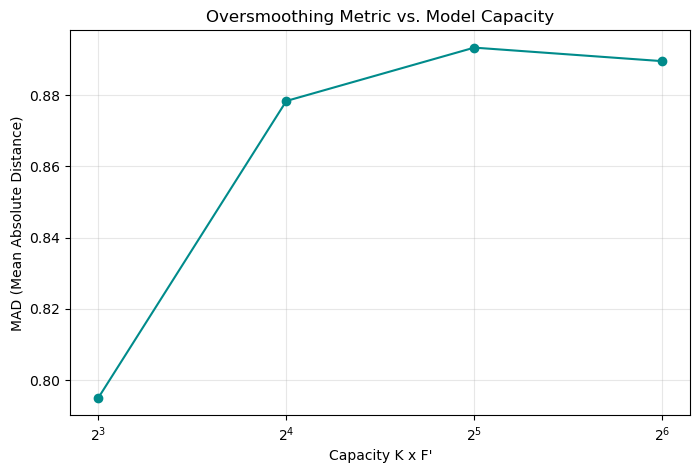

In [16]:
# Oversmoothing analysis: Mean Absolute Distance (MAD) vs Capacity.
s = summarize(df).reset_index()
gat_cap = s[s["kind"] == "GAT"].sort_values("KxFp")

plt.figure(figsize=(8, 5))
plt.plot(gat_cap["KxFp"], gat_cap["mad_mean"], "o-", color="darkcyan")
plt.xscale("log", base=2)
plt.xlabel("Capacity K x F'")
plt.ylabel("MAD (Mean Absolute Distance)")
plt.title("Oversmoothing Metric vs. Model Capacity")
plt.grid(True, alpha=0.3)
plt.show()

Computing embeddings for GCN...
Computing embeddings for GAT (K=8, F'=8)...


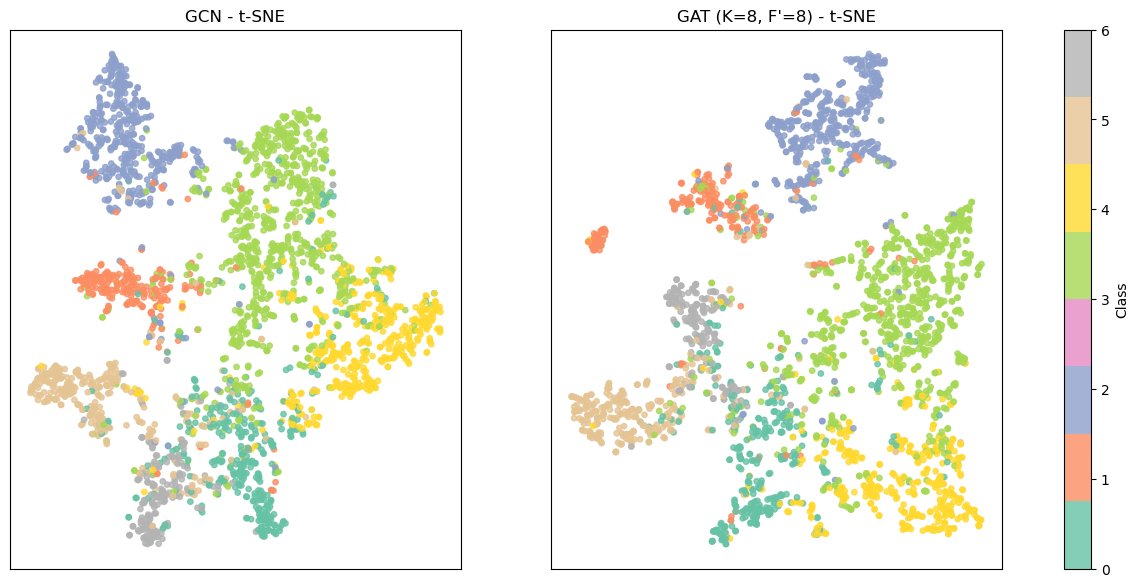

In [17]:
# t-SNE of final node embeddings: GCN vs GAT baseline (seed 0).
import torch
from sklearn.manifold import TSNE

def get_embeddings(cfg, seed: int = 0, epochs: int = 500): # Changed from 200 to 500
    set_seed(seed)
    model = build_model(cfg)
    opt   = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    crit  = torch.nn.CrossEntropyLoss()
    for _ in range(epochs):
        model.train()
        opt.zero_grad()
        out = model(data.x, data.edge_index)
        crit(out[data.train_mask], data.y[data.train_mask]).backward()
        opt.step()
    model.eval()
    with torch.no_grad():
        return model(data.x, data.edge_index)

panels = [("GCN", make_gcn_config()), ("GAT (K=8, F'=8)", make_gat_config(8, 8))]
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (title, cfg) in zip(axes, panels):
    print(f"Computing embeddings for {title}...")
    emb = get_embeddings(cfg).numpy()
    z   = TSNE(n_components=2, random_state=0).fit_transform(emb)
    sc  = ax.scatter(z[:, 0], z[:, 1], c=data.y.numpy(), cmap="Set2", s=15, alpha=0.8)
    ax.set_title(f"{title} - t-SNE")
    ax.set_xticks([])
    ax.set_yticks([])

plt.colorbar(sc, ax=axes, label="Class")
plt.savefig("tsne.png", dpi=150)
plt.show()